## Part III: ADJACENCY MATRICES

This section explores how graphs can be represented with matrices, what information can be read from those matrices, how weighted graphs change the representation, and why adjacency matrices are unusually interesting for strongly regular graphs.

In [16]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

### 1. What is an adjacency matrix?

A graph \(G(V,E)\) can be translated into a numerical representation which we call an adjacency matrix. Each vertex corresponds to one row and one column of the matrix. For a simple graph, if two vertices i and j are connected by an edge then \(A_{ij}=1\), otherwise \(A_{ij}=0\). The adjacency matrix for a simple undirected graph is symmetric as an edge connecting vertex i to vertex j also connects j to i. The diagonal entries are 0 as a vertex cannot be connected to itself in a simple undirected graph. (Lehman et al., 2010)

### 2. How does a graph translate into a matrix?

In order to construct an adjacency matrix, choose an ordering for the vertices. Each row and column represents one vertex. Enter 1 for every pair that is connected by an edge and 0 otherwise. Since undirected edges work in both directions, the matrix contains matching entries across the main diagonal. (Lehman et al., 2010)

Here is an example with the Petersen Graph and its adjacency matrix.

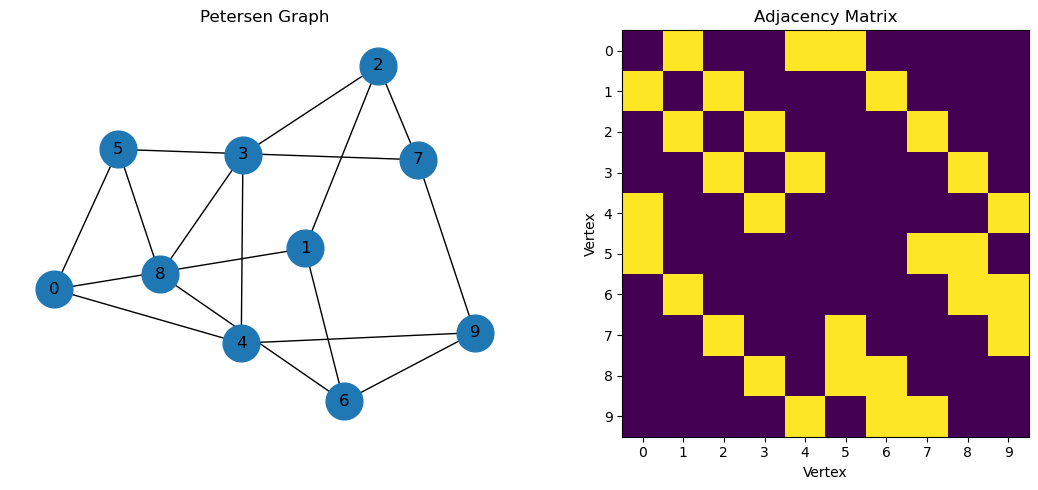

In [20]:
# Make the Petersen graph and its adjacency matrix
G = nx.petersen_graph()
A = nx.to_numpy_array(G, dtype=int)

# Graph and Matrix Display
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

nx.draw(G, with_labels=True, node_size=700, ax=axes[0])
axes[0].set_title("Petersen Graph")

axes[1].imshow(A)
axes[1].set_title("Adjacency Matrix")
axes[1].set_xlabel("Vertex")
axes[1].set_ylabel("Vertex")
axes[1].set_xticks(range(10))
axes[1].set_yticks(range(10))

plt.tight_layout()
plt.show()

Figure 1. The Petersen graph and its adjacency matrix.

### 3. What information can we get from an adjacency matrix?

The degree of a vertex equals the number of entries equal to 1 since each 1 represents a neighbor of the vertex. Powers of the adjacency 
matrix contain additional information about movement through the graph. In particular, the entry \((A^2)_{ij}\) counts the number of two-step 
walks from vertex \(i\) to vertex \(j\). For two different vertices, this also gives the number of common neighbors they share. (Lehman et al., 2010)

In [19]:
# degree of each vertex given by the sum of the row
degrees = A.sum(axis=1)

# A^2 contains the number of two step walks
A2 = A @ A

print("Degree of each vertex:")
print(degrees)

print("\nA squared:")
print(A2)

Degree of each vertex:
[3 3 3 3 3 3 3 3 3 3]

A squared:
[[3 0 1 1 0 0 1 1 1 1]
 [0 3 0 1 1 1 0 1 1 1]
 [1 0 3 0 1 1 1 0 1 1]
 [1 1 0 3 0 1 1 1 0 1]
 [0 1 1 0 3 1 1 1 1 0]
 [0 1 1 1 1 3 1 0 0 1]
 [1 0 1 1 1 1 3 1 0 0]
 [1 1 0 1 1 0 1 3 1 0]
 [1 1 1 0 1 0 0 1 3 1]
 [1 1 1 1 0 1 0 0 1 3]]


Considering the Petersen graph, every row sums to 3, meaning each vertex has degree 3. In \(A^2\), the diagonal entries are 3 as well. The off-diagonal entries show the number of common neighbors shared by pairs of different vertices.

### 4. What changes when the graph is weighted?

In a weighted graph, the entries of the adjacency matrix do not have to be only 0 or 1. Instead, \(A_{ij}\) can contain the numerical weight 
assigned to the edge between vertices \(i\) and \(j\). Depending on the graph, this weight might represent distance, cost, capacity, or 
another quantity. (Lehman et al., 2010) The sum of the row then represents the weighted degree, or total strength, instead of only the number of neighbors.

### 5. Why are adjacency matrices particularly interesting for strongly regular graphs?

A strongly regular graph has parameters \((v,k,\lambda,\mu)\) with \(v\) vertices where each vertex has a degree of \(k\), every pair of adjacent vertices has \(\lambda\) common neighbors, and each pair of non-adjacent vertices has \(\mu\) common neighbors.
Because the entries of \(A^2\) count two-step walks, they also count common neighbors, so the strongly regular condition can be expressed as
$$
A^2 = kI + \lambda A + \mu(J-I-A).
$$
\(I\) is the identity matrix and \(J\) is the matrix whose entries are all 1. This equation expresses the common neighbor structure of a strongly regular graph as a single matrix identity. (Spielman, 2009)




### Example 1: Petersen Graph

The Petersen graph is an SRG \((10,3,0,1)\). The graph has 10 vertices, where each vertex has a degree of 3, adjacent vertices have 0 common neighbors, and non-adjacent vertices have 1 common neighbor.
If we substitute these values into the general identity, we get
$$
A^2 = 2I - A + J.
$$

In [18]:
# Verifying the strongly regular graph identity for the Petersen graph
n = A.shape[0]
I = np.eye(n, dtype=int)
J = np.ones((n, n), dtype=int)

left_side = A @ A
right_side = 2 * I - A + J

print("Does A^2 = 2I - A + J?")
print(np.array_equal(left_side, right_side))

Does A^2 = 2I - A + J?
True


The output True verifies that the Petersen graph satisfies the adjacency-matrix identity associated with its strongly regular graph parameters.

### Example 2: Cycle Graph \(C_5\)

The cycle graph \(C_5\) is an SRG \((5,2,0,1)\). (Spielman, 2009) Each vertex has a degree of 2, adjacent vertices have no common neighbors, and non-adjacent vertices have exactly one common neighbor. Its matrix identity is
$$
A^2 = I - A + J.
$$

In [15]:
# C5 and verifying its strongly regular graph identity
C5 = nx.cycle_graph(5)
B = nx.to_numpy_array(C5, dtype=int)

I5 = np.eye(5, dtype=int)
J5 = np.ones((5, 5), dtype=int)

print("C5 adjacency matrix:")
print(B)

print("\nDegree of each vertex:")
print(B.sum(axis=1))

print("\nDoes B^2 = I - B + J?")
print(np.array_equal(B @ B, I5 - B + J5))

C5 adjacency matrix:
[[0 1 0 0 1]
 [1 0 1 0 0]
 [0 1 0 1 0]
 [0 0 1 0 1]
 [1 0 0 1 0]]

Degree of each vertex:
[2 2 2 2 2]

Does B^2 = I - B + J?
True


The \(C_5\) computation gives a degree of 2 for each vertex and returns True for its SRG matrix identity. Both the \(C_5\) and the Petersen graph show the same type of strongly regular matrix structure.

### References

Lehman, E., Leighton, F. T., & Meyer, A. R. (2010). Mathematics for Computer Science: Chapter 5, Graph Theory. MIT OpenCourseWare.
https://ocw.mit.edu/courses/6-042j-mathematics-for-computer-science-fall-2010/f471f7b7034fabe8bbba5507df7d307f_MIT6_042JF10_chap05.pdf

Spielman, D. A. (2009). Lecture 23: Strongly Regular Graphs, Part 1. Spectral Graph Theory, Yale University.
https://www.cs.yale.edu/homes/spielman/561/2009/lect23-09.pdf